In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('/kaggle/input/datasets/brycecf/give-me-some-credit-dataset/cs-training.csv', index_col=0)

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (150000, 11)

Columns: ['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']

First 5 rows:


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


Target distribution:
SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64

Percentage:
SeriousDlqin2yrs
0    93.3
1     6.7
Name: proportion, dtype: float64


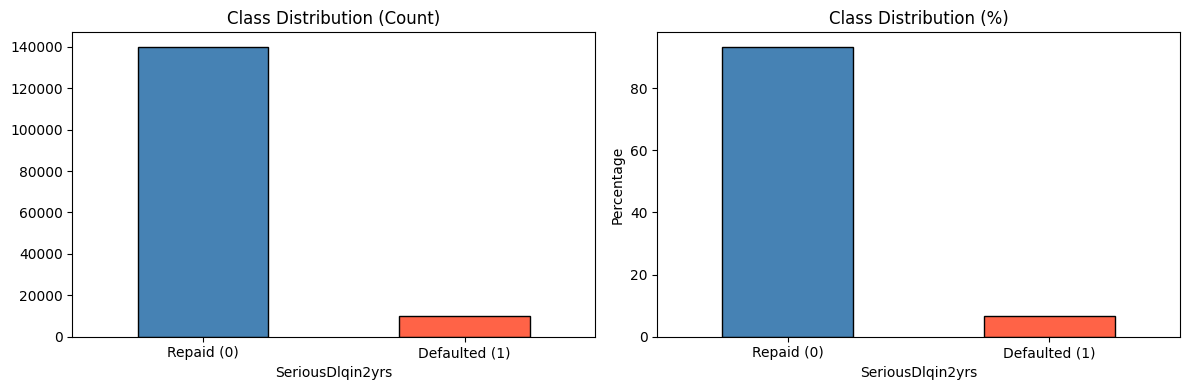

In [2]:
# Class distribution
print("Target distribution:")
print(df['SeriousDlqin2yrs'].value_counts())
print("\nPercentage:")
print(df['SeriousDlqin2yrs'].value_counts(normalize=True).round(3) * 100)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['SeriousDlqin2yrs'].value_counts().plot(
    kind='bar', ax=axes[0], color=['steelblue', 'tomato'], edgecolor='black'
)
axes[0].set_title('Class Distribution (Count)')
axes[0].set_xticklabels(['Repaid (0)', 'Defaulted (1)'], rotation=0)

df['SeriousDlqin2yrs'].value_counts(normalize=True).mul(100).plot(
    kind='bar', ax=axes[1], color=['steelblue', 'tomato'], edgecolor='black'
)
axes[1].set_title('Class Distribution (%)')
axes[1].set_xticklabels(['Repaid (0)', 'Defaulted (1)'], rotation=0)
axes[1].set_ylabel('Percentage')

plt.tight_layout()
plt.show()

In [3]:
# Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print("Missing Values:")
print(missing_df[missing_df['Missing Count'] > 0])

Missing Values:
                    Missing Count  Missing %
MonthlyIncome               29731      19.82
NumberOfDependents           3924       2.62


In [4]:
# Basic statistics
print("Dataset Statistics:")
df.describe().round(2)

Dataset Statistics:


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.00,150000.00,150000.00,150000.00,150000.00,120269.00,150000.00,150000.00,150000.00,150000.00,146076.00
mean,0.07,6.05,52.30,0.42,353.01,6670.22,8.45,0.27,1.02,0.24,0.76
std,0.25,249.76,14.77,4.19,2037.82,14384.67,5.15,4.17,1.13,4.16,1.12
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.03,41.00,0.00,0.18,3400.00,5.00,0.00,0.00,0.00,0.00
50%,0.00,0.15,52.00,0.00,0.37,5400.00,8.00,0.00,1.00,0.00,0.00
75%,0.00,0.56,63.00,0.00,0.87,8249.00,11.00,0.00,2.00,0.00,1.00
max,1.00,50708.00,109.00,98.00,329664.00,3008750.00,58.00,98.00,54.00,98.00,20.00


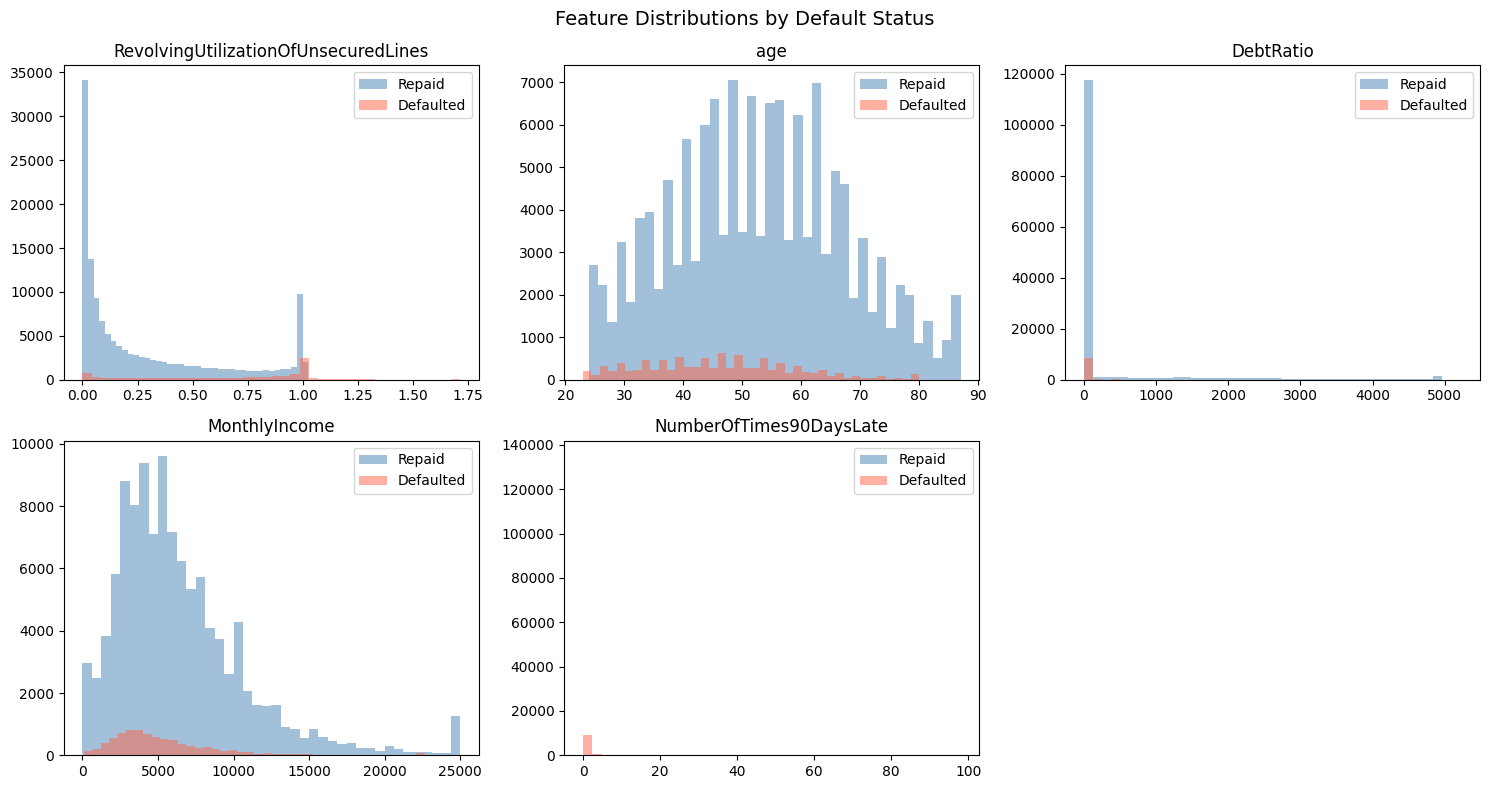

In [5]:
# Feature distributions split by target
features = [
    'RevolvingUtilizationOfUnsecuredLines',
    'age',
    'DebtRatio',
    'MonthlyIncome',
    'NumberOfTimes90DaysLate'
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    for label, color in [(0, 'steelblue'), (1, 'tomato')]:
        subset = df[df['SeriousDlqin2yrs'] == label][col].dropna()
        subset = subset.clip(subset.quantile(0.01), subset.quantile(0.99))
        axes[i].hist(subset, bins=40, alpha=0.5, color=color,
                     label='Repaid' if label == 0 else 'Defaulted')
    axes[i].set_title(col)
    axes[i].legend()

axes[-1].set_visible(False)
plt.suptitle('Feature Distributions by Default Status', fontsize=14)
plt.tight_layout()
plt.show()

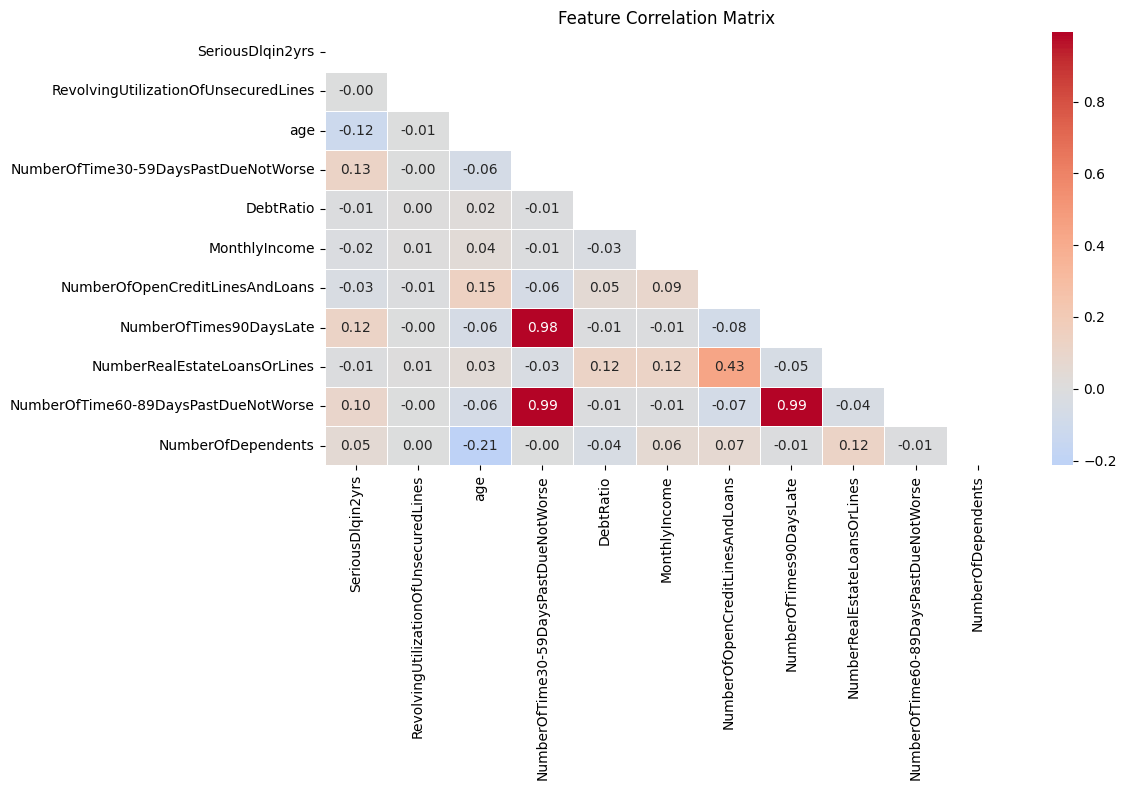

In [6]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()